# YOLOv8 Fine-tuning — Stairs Detection
**Objectif** : Fine-tuner YOLOv8n pour détecter les escaliers (classe absente de COCO)  
**Données**  : Open Images V7 — 4533 images annotées stairs  
**Output**   : `yolov8n_stairs.pt` — intégrable dans le pipeline Object-Finder

## 1. Installation & Imports

In [1]:
!pip install ultralytics --quiet
print("Ultralytics installé")
!pip install fiftyone --quiet
print("FiftyOne installé")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00
Ultralytics installé
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 k

In [2]:
import os
import shutil
import torch
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from ultralytics import YOLO
import fiftyone as fo
import fiftyone.zoo as foz
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')

print("Imports OK")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Imports OK


## 2. Chargement des annotations

In [3]:
# Charger le CSV produit par 1_EDA_Preprocessing_Stairs
BASE_INPUT = "/kaggle/input/notebooks/medkhalilkh/1-eda-preprocessing-stairs"

df = pd.read_csv(f"{BASE_INPUT}/stairs_annotations.csv")

print(f"Annotations totales : {len(df)}")
print(f"\nRépartition split :")
print(df["split"].value_counts())
print(f"\nAperçu :")
print(df.head(3))
print(f"\nColonnes : {df.columns.tolist()}")

Annotations totales : 6026

Répartition split :
split
train    5981
val        45
Name: count, dtype: int64

Aperçu :
                                            filepath   label    x_norm  \
0  /root/fiftyone/open-images-v7/train/data/0003a...  stairs  0.659375   
1  /root/fiftyone/open-images-v7/train/data/00043...  stairs  0.603750   
2  /root/fiftyone/open-images-v7/train/data/0007a...  stairs  0.000000   

     y_norm    w_norm    h_norm      area  split  
0  0.364167  0.143750  0.292500  0.042047  train  
1  0.579167  0.395625  0.420000  0.166163  train  
2  0.000000  0.399375  0.999115  0.399022  train  

Colonnes : ['filepath', 'label', 'x_norm', 'y_norm', 'w_norm', 'h_norm', 'area', 'split']


## 3.Split 80/20

In [4]:
# Refaire un split aléatoire sur toutes les images

# Grouper par image (pas par annotation)
images_uniques = df.drop_duplicates("filepath")

train_imgs, val_imgs = train_test_split(
    images_uniques["filepath"].tolist(),
    test_size=0.20,
    random_state=42
)

df["split"] = df["filepath"].apply(
    lambda x: "train" if x in train_imgs else "val"
)

print(f"Train images : {len(train_imgs)}")
print(f"Val images   : {len(val_imgs)}")

Train images : 3655
Val images   : 914


## 4. Conversion au format YOLO

In [5]:
# Format YOLO pour chaque annotation :
# <class_id> <x_center> <y_center> <width> <height>  (normalisé 0-1)
#
# Open Images V7 fournit [x_min, y_min, width, height] normalisé
# YOLO attend   [x_center, y_center, width, height]  normalisé
#
# Conversion :
#   x_center = x_min + width/2
#   y_center = y_min + height/2

CLASS_ID = 0

def convert_to_yolo(x_norm, y_norm, w_norm, h_norm):
    """
    Convertit bbox Open Images → format YOLO.
    Open Images : x_norm=x_min, y_norm=y_min
    YOLO        : x_center, y_center
    """
    x_center = x_norm + w_norm / 2
    y_center = y_norm + h_norm / 2
    return x_center, y_center, w_norm, h_norm

# Test conversion
row = df.iloc[0]
xc, yc, w, h = convert_to_yolo(row["x_norm"], row["y_norm"],
                                row["w_norm"], row["h_norm"])
print(f"Exemple conversion :")
print(f"  Open Images : x={row['x_norm']:.4f} y={row['y_norm']:.4f} w={row['w_norm']:.4f} h={row['h_norm']:.4f}")
print(f"  YOLO        : x_c={xc:.4f} y_c={yc:.4f} w={w:.4f} h={h:.4f}")

# Vérification — toutes les valeurs doivent être entre 0 et 1
df["x_center"] = df["x_norm"] + df["w_norm"] / 2
df["y_center"] = df["y_norm"] + df["h_norm"] / 2

assert (df["x_center"].between(0, 1)).all(), "x_center hors [0,1]"
assert (df["y_center"].between(0, 1)).all(), "y_center hors [0,1]"
assert (df["w_norm"].between(0, 1)).all(),   "width hors [0,1]"
assert (df["h_norm"].between(0, 1)).all(),   "height hors [0,1]"

print("\nToutes les coordonnées sont valides [0,1]")

Exemple conversion :
  Open Images : x=0.6594 y=0.3642 w=0.1437 h=0.2925
  YOLO        : x_c=0.7313 y_c=0.5104 w=0.1437 h=0.2925

Toutes les coordonnées sont valides [0,1]


## 5. Construction du dataset YOLO

### Structure attendue par YOLOv8 :
### dataset/
### ├── images/
### │   ├── train/  → .jpg
### │   └── val/    → .jpg
### └── labels/
###     ├── train/  → .txt
###     └── val/    → .txt

In [6]:
# Retélécharger les images originales Open Images V7
try:
    dataset = fo.load_dataset("stairs-openimages-train")
    print(f"Cache : {len(dataset)} images")
except:
    dataset = foz.load_zoo_dataset(
        "open-images-v7",
        split="train",
        label_types=["detections"],
        classes=["Stairs"],
        max_samples=10000,
        dataset_name="stairs-openimages-train"
    )

try:
    dataset_val = fo.load_dataset("stairs-openimages-val")
except:
    dataset_val = foz.load_zoo_dataset(
        "open-images-v7",
        split="validation",
        label_types=["detections"],
        classes=["Stairs"],
        dataset_name="stairs-openimages-val"
    )

print(f"Train : {len(dataset)} | Val : {len(dataset_val)}")

# Reconstruire df avec chemins locaux réels
rows = []
for sample in dataset:
    detections = sample.ground_truth.detections if sample.ground_truth else []
    for d in [x for x in detections if x.label == "Stairs"]:
        x, y, w, h = d.bounding_box
        if w * h >= 0.01:
            rows.append({"filepath": sample.filepath,
                         "x_norm": x, "y_norm": y,
                         "w_norm": w, "h_norm": h, "split": "train"})

for sample in dataset_val:
    detections = sample.ground_truth.detections if sample.ground_truth else []
    for d in [x for x in detections if x.label == "Stairs"]:
        x, y, w, h = d.bounding_box
        if w * h >= 0.01:
            rows.append({"filepath": sample.filepath,
                         "x_norm": x, "y_norm": y,
                         "w_norm": w, "h_norm": h, "split": "val"})

df = pd.DataFrame(rows)
print(f"{len(df)} annotations avec chemins locaux")
print(f"Exemple : {df.iloc[0]['filepath']}")

 100% |██████|    4.8Gb/4.8Gb [3.1s elapsed, 0s remaining, 1.7Gb/s]         
Only found 4533 (<10000) samples matching your requirements
 100% |█████████████████| 4533/4533 [4.7m elapsed, 0s remaining, 17.8 files/s]      
Dataset info written to '/root/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'train'
 100% |███████████████| 4533/4533 [22.6s elapsed, 0s remaining, 204.6 samples/s]      
Dataset 'stairs-openimages-train' created
 100% |█████████████████████| 36/36 [2.9s elapsed, 0s remaining, 16.4 files/s]      
Dataset info written to '/root/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'validation'
 100% |███████████████████| 36/36 [442.6ms elapsed, 0s remaining, 81.7 samples/s]  
Dataset 'stairs-openimages-val' created
Train : 4533 | Val : 36
5687 annotations avec chemins locaux
Exemple : /root/fiftyone/open-images-v7/train/data/0003a351caf34972.jpg


In [7]:
DATASET_DIR = Path("/kaggle/working/yolo_stairs")

for split in ["train", "val"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Structure créée :")
for p in sorted(DATASET_DIR.rglob("*")):
    if p.is_dir():
        print(f"  {p}")

Structure créée :
  /kaggle/working/yolo_stairs/images
  /kaggle/working/yolo_stairs/images/train
  /kaggle/working/yolo_stairs/images/val
  /kaggle/working/yolo_stairs/labels
  /kaggle/working/yolo_stairs/labels/train
  /kaggle/working/yolo_stairs/labels/val


In [8]:
# Grouper les annotations par image
# Une image peut avoir plusieurs bounding boxes escaliers
grouped = df.groupby(["filepath", "split"])

copied  = {"train": 0, "val": 0}
labeled = {"train": 0, "val": 0}
errors  = 0

for (filepath, split), group in grouped:
    try:
        # ── Copier l'image
        img_name = Path(filepath).stem + ".jpg"
        dst_img  = DATASET_DIR / "images" / split / img_name

        img = Image.open(filepath).convert("RGB")
        img.save(dst_img, quality=95)
        copied[split] += 1

        # ── Créer le fichier label .txt
        dst_lbl = DATASET_DIR / "labels" / split / (Path(filepath).stem + ".txt")

        with open(dst_lbl, "w") as f:
            for _, row in group.iterrows():
                xc = row["x_norm"] + row["w_norm"] / 2
                yc = row["y_norm"] + row["h_norm"] / 2
                w  = row["w_norm"]
                h  = row["h_norm"]
                # Clamp [0, 1] — sécurité
                xc = max(0.0, min(1.0, xc))
                yc = max(0.0, min(1.0, yc))
                w  = max(0.0, min(1.0, w))
                h  = max(0.0, min(1.0, h))
                f.write(f"{CLASS_ID} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

        labeled[split] += 1

    except Exception as e:
        errors += 1

print(f"Images copiées  — train: {copied['train']} | val: {copied['val']}")
print(f"Labels créés    — train: {labeled['train']} | val: {labeled['val']}")
print(f"Erreurs         : {errors}")

Images copiées  — train: 4461 | val: 36
Labels créés    — train: 4461 | val: 36
Erreurs         : 0


## 6. Fichier de configuration YAML

In [9]:
# data.yaml — fichier de configuration pour YOLOv8
# Indique les chemins et les classes

data_yaml = {
    "path":  str(DATASET_DIR),
    "train": "images/train",
    "val":   "images/val",
    "nc":    1,              # nombre de classes = 1 (stairs)
    "names": ["stairs"]      # nom de la classe
}

yaml_path = DATASET_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("Contenu data.yaml :")
with open(yaml_path) as f:
    print(f.read())

Contenu data.yaml :
names:
- stairs
nc: 1
path: /kaggle/working/yolo_stairs
train: images/train
val: images/val



## 7. Vérification visuelle des annotations

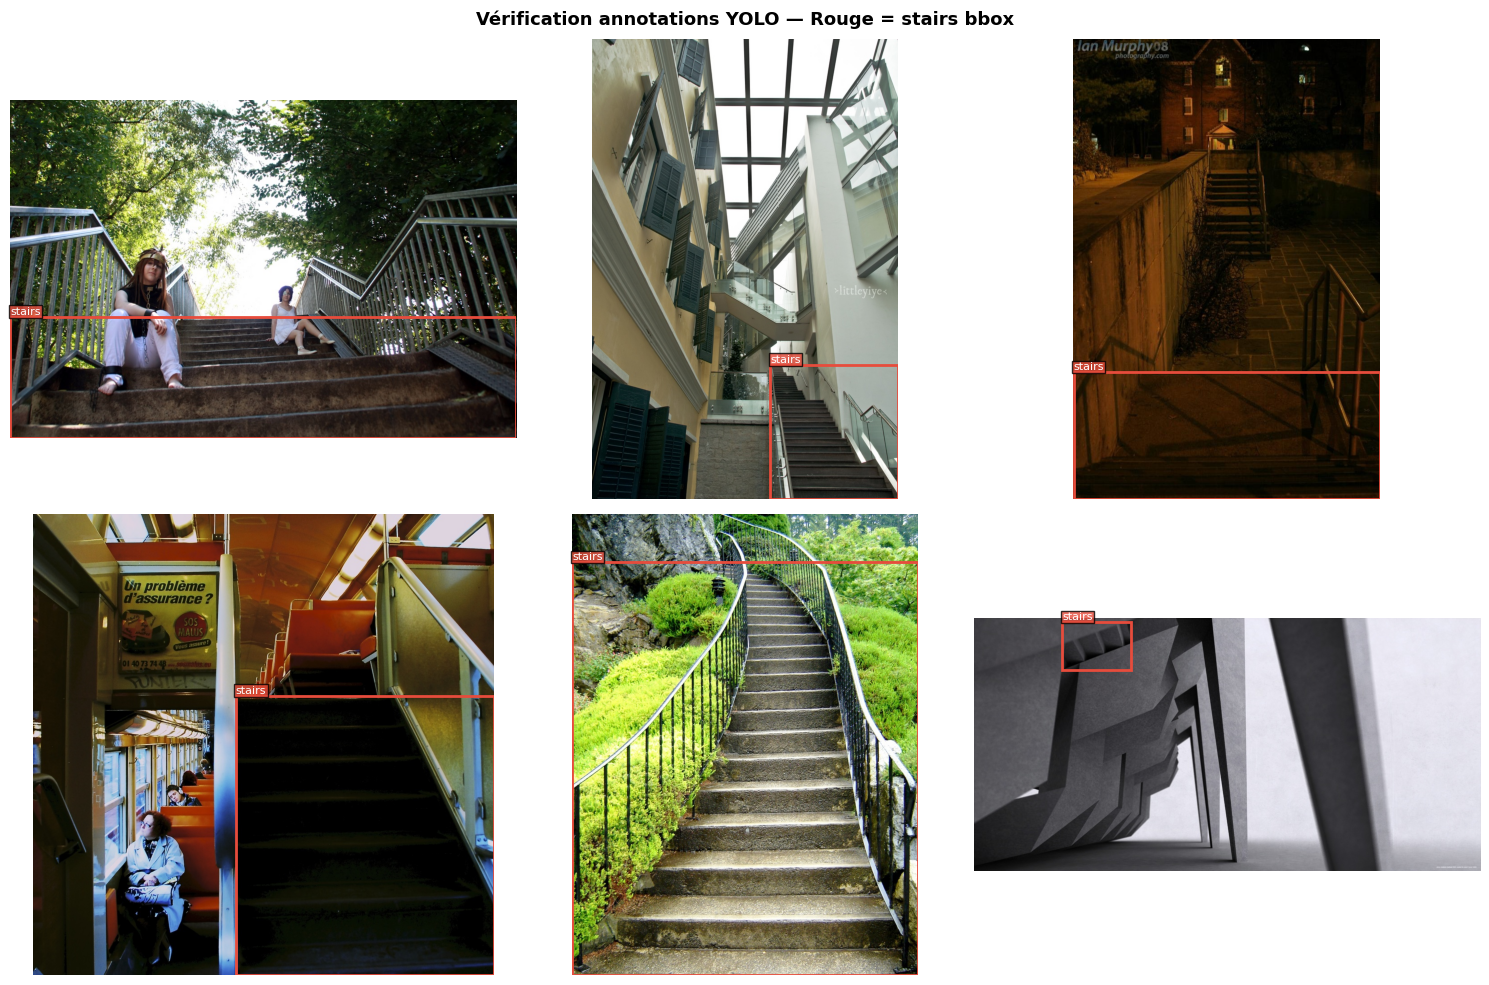

In [10]:
# Afficher 6 exemples avec bounding boxes dessinées
train_imgs = list((DATASET_DIR / "images" / "train").glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, img_path in enumerate(train_imgs):
    ax  = axes.flat[i]
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)

    # Charger le label correspondant
    lbl_path = DATASET_DIR / "labels" / "train" / (img_path.stem + ".txt")
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                _, xc, yc, w, h = map(float, parts)
                x1 = (xc - w/2) * W
                y1 = (yc - h/2) * H
                rect = patches.Rectangle(
                    (x1, y1), w*W, h*H,
                    linewidth=2, edgecolor="#e74c3c", facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x1, y1-5, "stairs",
                        color="white", fontsize=8,
                        bbox=dict(facecolor="#e74c3c", alpha=0.8, pad=1))
    ax.axis("off")

plt.suptitle("Vérification annotations YOLO — Rouge = stairs bbox",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Fine-tuning YOLOv8n

In [11]:
# Charger YOLOv8n pré-entraîné sur COCO (80 classes)
# Fine-tuner pour ajouter la classe "stairs"
model = YOLO("yolov8n.pt")
print("YOLOv8n chargé")
print(model.info())

YOLOv8n chargé
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
(129, 3157200, 0, 8.8575488)


In [12]:
# Fine-tuning
# Hyperparamètres optimisés pour petit dataset (4533 images)
device = 0 if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

results = model.train(
    data    = str(yaml_path),
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    lr0     = 0.001,          # lr initial
    lrf     = 0.01,           # lr final = lr0 × lrf
    momentum= 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 3,         # warmup 3 epochs → stabilise le début
    mosaic  = 1.0,            # augmentation mosaic — combine 4 images
    flipud  = 0.1,            # flip vertical
    fliplr  = 0.5,            # flip horizontal
    degrees = 10.0,           # rotation
    translate= 0.1,           # translation
    scale   = 0.5,            # zoom
    hsv_h   = 0.015,          # variation teinte
    hsv_s   = 0.7,            # variation saturation
    hsv_v   = 0.4,            # variation luminosité
    patience= 15,             # early stopping si pas d'amélioration
    device  = device,         # GPU
    project = "/kaggle/working/yolo_training",
    name    = "stairs_v1",
    exist_ok= True,
    verbose = True
)

print(f"\nEntraînement terminé")
print(f"mAP50   : {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"mAP50-95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")

Device : 0
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_stairs/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stairs_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

## 9. Évaluation

In [13]:
# Évaluer sur le set de validation
metrics = model.val(data=str(yaml_path))

print("\n" + "="*45)
print("   ÉVALUATION — YOLOv8n Stairs")
print("="*45)
print(f"  mAP50        : {metrics.box.map50:.4f}")
print(f"  mAP50-95     : {metrics.box.map:.4f}")
print(f"  Précision    : {metrics.box.mp:.4f}")
print(f"  Rappel       : {metrics.box.mr:.4f}")
print("="*45)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3461.5±1515.7 MB/s, size: 327.3 KB)
val: Scanning /kaggle/working/yolo_stairs/labels/val.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.6it/s 1.2s
                   all         36         44      0.561      0.591      0.628      0.393
Speed: 7.3ms preprocess, 10.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

   ÉVALUATION — YOLOv8n Stairs
  mAP50        : 0.6276
  mAP50-95     : 0.3929
  Précision    : 0.5613
  Rappel       : 0.5909


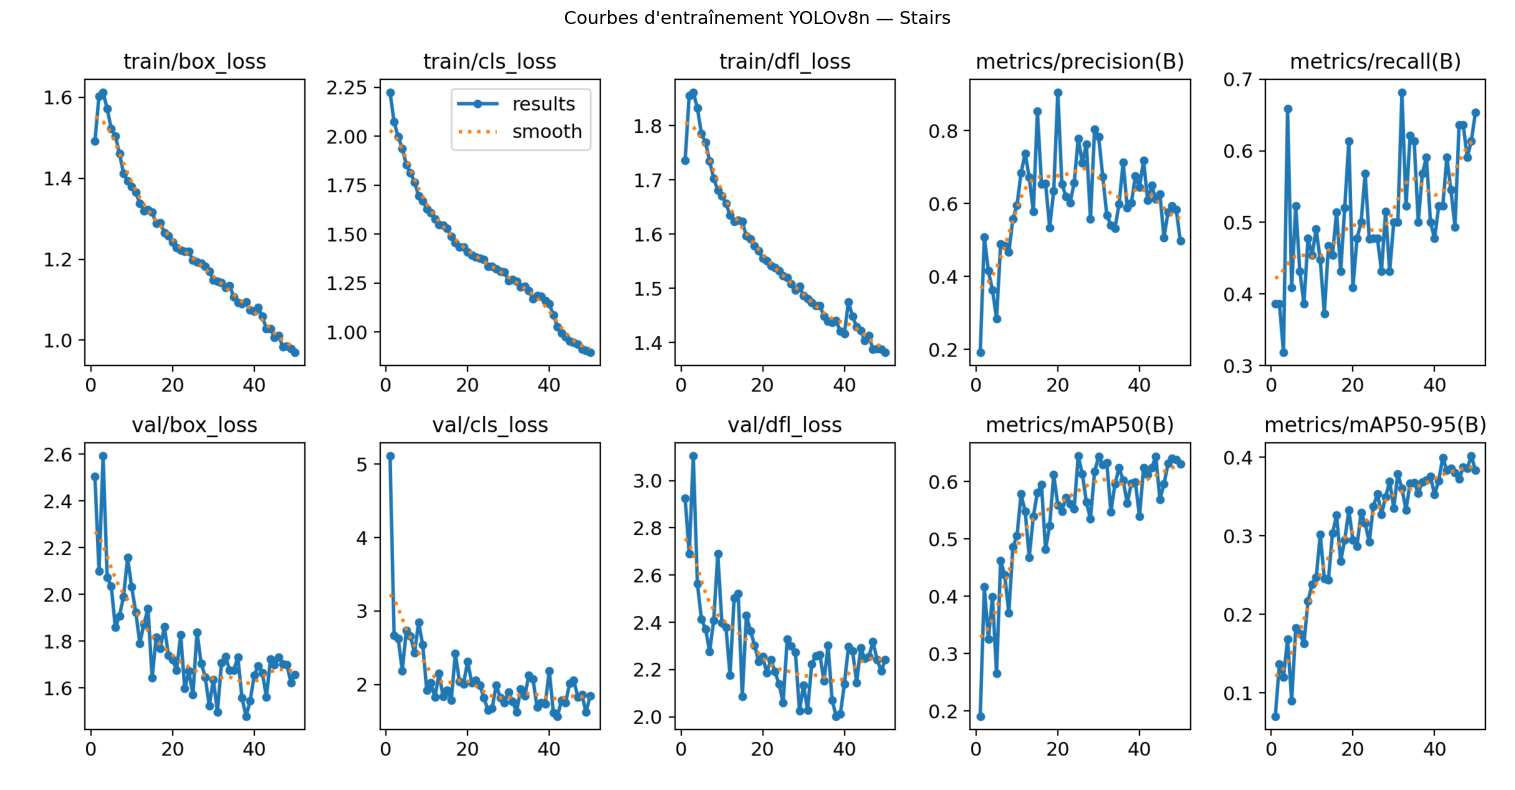

In [14]:
# Courbes d'entraînement
results_dir = Path("/kaggle/working/yolo_training/stairs_v1")

if (results_dir / "results.png").exists():
    img = Image.open(results_dir / "results.png")
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Courbes d'entraînement YOLOv8n — Stairs", fontsize=13)
    plt.tight_layout()
    plt.show()

## 10. Test visuel sur images val

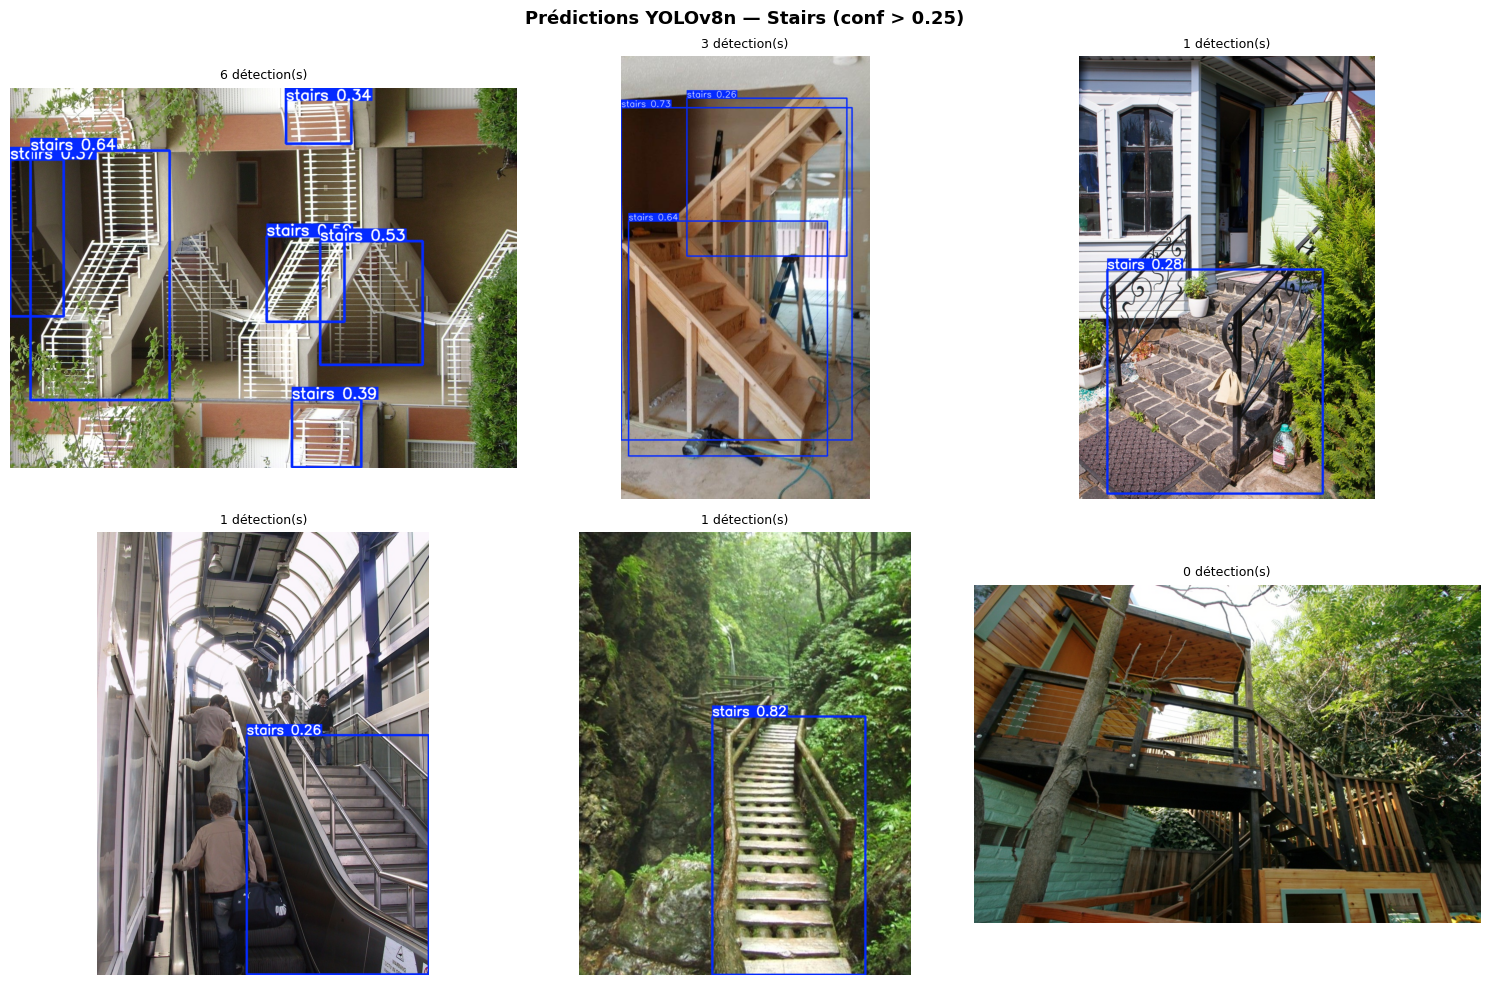

In [15]:
# Tester sur 6 images de validation
val_imgs = list((DATASET_DIR / "images" / "val").glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, img_path in enumerate(val_imgs):
    ax = axes.flat[i]

    # Prédiction
    result = model(str(img_path), conf=0.25, verbose=False)[0]
    img_annotated = result.plot()
    ax.imshow(img_annotated[:, :, ::-1])  # BGR → RGB

    n_det = len(result.boxes)
    ax.set_title(f"{n_det} détection(s)", fontsize=9)
    ax.axis("off")

plt.suptitle("Prédictions YOLOv8n — Stairs (conf > 0.25)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Sauvegarde du modèle

In [16]:
# Copier le meilleur modèle vers /kaggle/working/
best_model = Path("/kaggle/working/yolo_training/stairs_v1/weights/best.pt")
output_path = Path("/kaggle/working/yolov8n_stairs.pt")

shutil.copy2(best_model, output_path)
print(f"Modèle sauvegardé : {output_path}")
print(f"Taille           : {output_path.stat().st_size / 1024 / 1024:.1f} MB")

Modèle sauvegardé : /kaggle/working/yolov8n_stairs.pt
Taille           : 5.9 MB
